In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
plt.style.use('ggplot')

data = np.array([
    0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
    0, 1, 1, 1, 0, 0, 0, 3, 0, 3, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 0, 1, 1,
    1, 0, 0, 1, 0, 1, 2, 3, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0
])

n = len(data)
print(f"Об'єм вибірки (n): {n}")

Об'єм вибірки (n): 100


In [3]:
values, counts = np.unique(data, return_counts=True)
probabilities = counts / n 

stat_series = pd.DataFrame({
    'Значення (x_i)': values,
    'Частота (n_i)': counts,
    'Відносна частота (w_i)': probabilities
})

print("Статистичний ряд:")
display(stat_series) 

Статистичний ряд:


,Значення (x_i),Частота (n_i),Відносна частота (w_i)
0,0,69,0.69
1,1,24,0.24
2,2,3,0.03
3,3,4,0.04


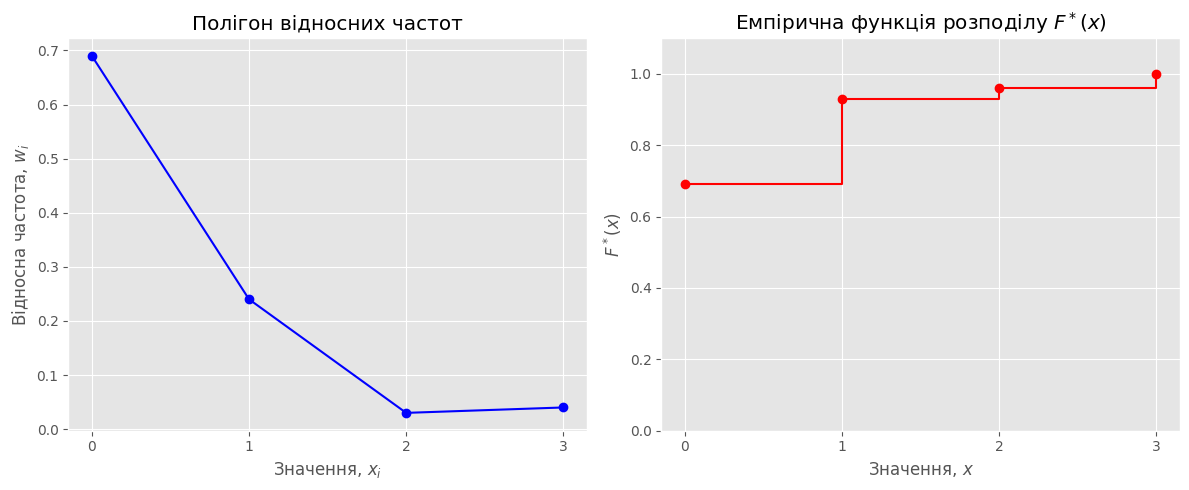

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(values, probabilities, marker='o', linestyle='-', color='b')
plt.title("Полігон відносних частот")
plt.xlabel("Значення, $x_i$")
plt.ylabel("Відносна частота, $w_i$")
plt.xticks(values)

plt.subplot(1, 2, 2)
ecdf = np.cumsum(probabilities)

plt.step(values, ecdf, where='post', color='r', marker='o')
plt.title("Емпірична функція розподілу $F^*(x)$")
plt.xlabel("Значення, $x$")
plt.ylabel("$F^*(x)$")
plt.xticks(values)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [10]:
mean_val = np.mean(data)

var_b = np.var(data, ddof=0) 

var_s = np.var(data, ddof=1)

median_val = np.median(data)
mode_val = stats.mode(data, keepdims=True)[0][0]

skewness = stats.skew(data)
kurtosis = stats.kurtosis(data)

print("------- Точкові оцінки параметрів вибірки")
print(f"Вибіркове середнє (x_mean): {mean_val:.4f}")
print(f"Вибіркова дисперсія (D_B):  {var_b:.4f}")
print(f"Виправлена дисперсія (S^2): {var_s:.4f}")
print(f"Вибіркова медіана:          {median_val}")
print(f"Вибіркова мода:             {mode_val}")
print(f"Коефіцієнт асиметрії:       {skewness:.4f}")
print(f"Коефіцієнт ексцесу:         {kurtosis:.4f}")

------- Точкові оцінки параметрів вибірки
Вибіркове середнє (x_mean): 0.4200
Вибіркова дисперсія (D_B):  0.5436
Виправлена дисперсія (S^2): 0.5491
Вибіркова медіана:          0.0
Вибіркова мода:             0
Коефіцієнт асиметрії:       1.9985
Коефіцієнт ексцесу:         3.7949


In [9]:
a_est = mean_val
p_est = 1 / (a_est + 1)

print("------Оцінка параметрів розподілу")
print(f"Оцінка параметра a (a_est): {a_est:.4f}")
print(f"Оцінка ймовірності p (p_est): {p_est:.4f}")

var_theoretical = a_est * (a_est + 1)
print(f"Теоретична дисперсія D(X) при a={a_est:.4f}: {var_theoretical:.4f}")
print(f"Вибіркова дисперсія S^2: {var_s:.4f}")

------Оцінка параметрів розподілу
Оцінка параметра a (a_est): 0.4200
Оцінка ймовірності p (p_est): 0.7042
Теоретична дисперсія D(X) при a=0.4200: 0.5964
Вибіркова дисперсія S^2: 0.5491


In [11]:
gamma = 0.95
alpha = 1 - gamma

z_value = stats.norm.ppf(1 - alpha / 2)

se = np.sqrt(var_s / n)

ci_lower_a = a_est - z_value * se
ci_upper_a = a_est + z_value * se

print(f"------Довірчі інтервали (надійність {gamma})")
print(f"Квантиль Z: {z_value:.4f}")
print(f"Стандартна похибка (SE): {se:.4f}")
print(f"Довірчий інтервал для параметра a: ({ci_lower_a:.4f} ; {ci_upper_a:.4f})")

ci_lower_p = 1 / (ci_upper_a + 1)
ci_upper_p = 1 / (ci_lower_a + 1)

print(f"Довірчий інтервал для параметра p: ({ci_lower_p:.4f} ; {ci_upper_p:.4f})")

------Довірчі інтервали (надійність 0.95)
Квантиль Z: 1.9600
Стандартна похибка (SE): 0.0741
Довірчий інтервал для параметра a: (0.2748 ; 0.5652)
Довірчий інтервал для параметра p: (0.6389 ; 0.7845)


In [13]:
n_obs = np.array([counts[0], counts[1], np.sum(counts[2:])])
print(f"Спостережувані частоти (n_i): {n_obs}")

p_0 = p_est
p_1 = (1 - p_est) * p_est
p_ge2 = 1 - (p_0 + p_1)
p_theo = np.array([p_0, p_1, p_ge2])

n_theo = n * p_theo
print(f"Теоретичні частоти (n*p_i):  {n_theo}")

chi2_obs = np.sum((n_obs - n_theo)**2 / n_theo)

alpha = 0.05
df = len(n_obs) - 1 - 1 # k - 1 - r
chi2_crit = stats.chi2.ppf(1 - alpha, df)

print("-----------------------------------")
print(f"Спостережуване значення chi2: {chi2_obs:.4f}")
print(f"Критичне значення chi2 (alpha=0.05, df={df}): {chi2_crit:.4f}")

if chi2_obs < chi2_crit:
    print("Висновок: Гіпотеза ПРИЙМАЄТЬСЯ. Дані узгоджуються з геометричним розподілом.")
else:
    print("Висновок: Гіпотеза ВІДХИЛЯЄТЬСЯ.")

Спостережувані частоти (n_i): [69 24  7]
Теоретичні частоти (n*p_i):  [70.42253521 20.82920056  8.74826423]
-----------------------------------
Спостережуване значення chi2: 0.8608
Критичне значення chi2 (alpha=0.05, df=1): 3.8415
Висновок: Гіпотеза ПРИЙМАЄТЬСЯ. Дані узгоджуються з геометричним розподілом.
